<a href="https://colab.research.google.com/github/Nurdaulet12/project-1/blob/main/Loan_Prediction_Dataset_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#  ЖОБА 2 — НЕСИЕ ПОРТФЕЛІН ТАЛДАУ
# ============================================================
#
#  Датасет: Loan Prediction Dataset (Kaggle)
#  Негізгі сұрақ: "Несие портфелі қалай құрылған және
#                  қай жерде тәуекел ең жоғары?"
#
#  Талдау форматы:
#  1. Descriptive  — қарыз алушылар кім?
#  2. Diagnostic   — кімдер неге бас тартуға ұшырайды?
#  3. Predictive   — өтінімдер динамикасы қандай?
#  4. Prescriptive — несие саясатын қалай жақсартуға болады?
#
# ============================================================


Nurdaulet

#0. ДЕРЕКТЕРДІ ЖҮКТЕУ ЖӘНЕ АЛҒАШҚЫ ШОЛУ


In [ ]:
#  Керек libraries жүктеп аламыз
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

In [ ]:
df = pd.read_csv('loan_2.csv')

print("=== АЛҒАШҚЫ 5 ЖОЛДЫ ҚАРАУ ===")
print(df.head())

print("\n=== ӨЛШЕМІ ===")
print(df.shape)

print("\n=== БАҒАНДАР ТУРАЛЫ АҚПАРАТ ===")
df.info()

print("\n=== САНДЫҚ СТАТИСТИКА ===")
print(df.describe())


=== АЛҒАШҚЫ 5 ЖОЛДЫ ҚАРАУ ===
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural     

# 1. ДЕРЕКТЕРДІ ТАЗАЛАУ

In [ ]:
print("\n=== БОС МӘНДЕР ===")
print(df.isnull().sum())



=== БОС МӘНДЕР ===
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [ ]:
# TODO 7: 'Loan_Amount_Term' бағанындағы бос мәндерді модамен толтыру
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

/tmp/ipykernel_2833/215547790.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)


In [ ]:
# TODO 8: 'Gender', 'Married', 'Self_Employed', 'Credit_History' бағандарындағы
#          бос мәндерді модамен толтыру
for col in ['Gender', 'Married', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# TODO 9: Қайталанатын жолдарды жою
df.drop_duplicates(inplace=True)


# 2. DESCRIPTIVE ТАЛДАУ — "Қарыз алушылар кім?"

In [ ]:
print("\n=== 2. DESCRIPTIVE ТАЛДАУ ===")

# 2.1 Несие мәртебесі — қанша пайыз мақұлданды?
print("\n--- Несие мәртебесі ---")
# TODO 10: 'Loan_Status' бойынша value_counts шығару (пайызбен)
print(df['Loan_Status'].value_counts(normalize=True) * 100)


=== 2. DESCRIPTIVE ТАЛДАУ ===

--- Несие мәртебесі ---
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [ ]:
# 2.2 Білім деңгейі бойынша бөліну
print("\n--- Білім деңгейі ---")
# TODO 11: 'Education' бойынша value_counts шығару
print(df['Education'].value_counts())


--- Білім деңгейі ---
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


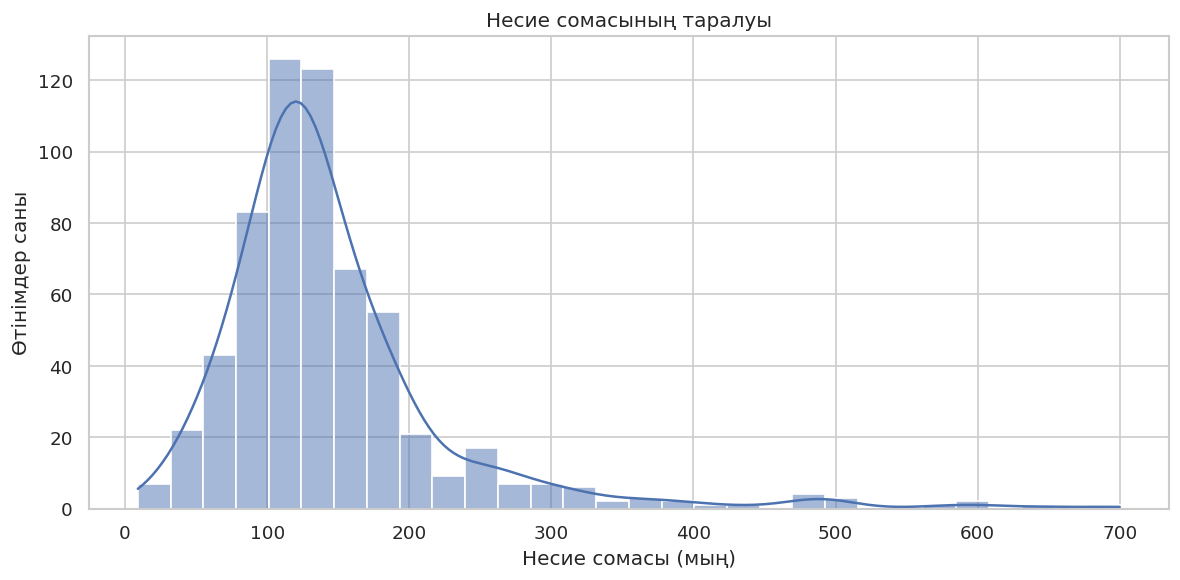

In [ ]:
# 2.3 Несие сомасының таралуы
# TODO 12: 'LoanAmount' үшін histplot сал (bins=30, kde=True)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['LoanAmount'], bins=30, kde=True, ax=ax)
ax.set_title('Несие сомасының таралуы')
ax.set_xlabel('Несие сомасы (мың)')
ax.set_ylabel('Өтінімдер саны')
plt.tight_layout()
plt.show()

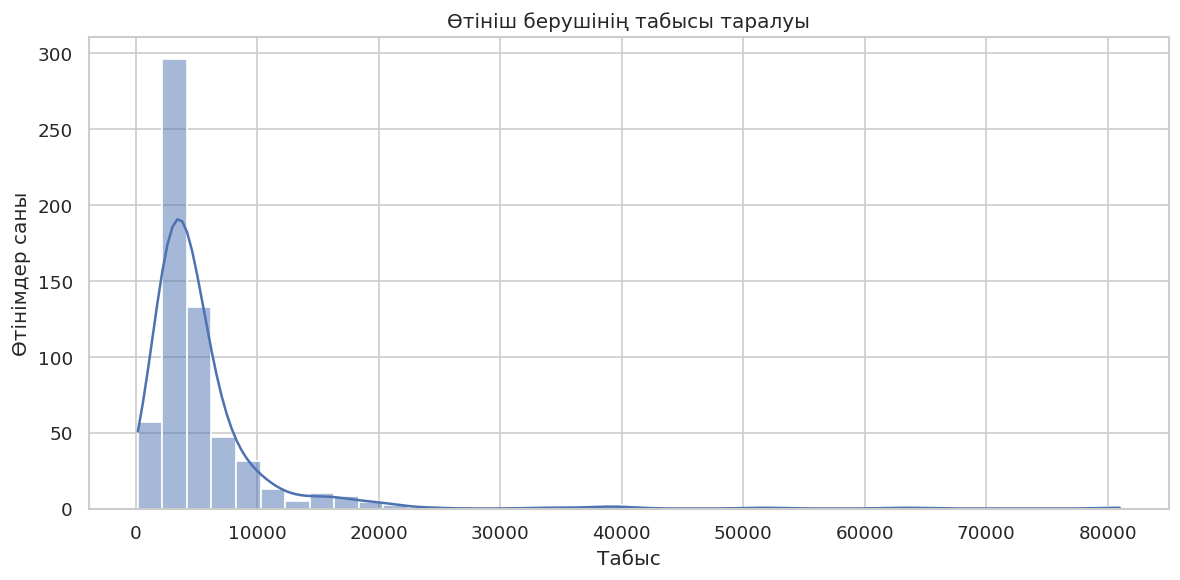

In [ ]:
# 2.4 Табыс таралуы
# TODO 13: 'ApplicantIncome' үшін histplot сал (bins=40, kde=True)
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['ApplicantIncome'], bins=40, kde=True, ax=ax)
ax.set_title('Өтініш берушінің табысы таралуы')
ax.set_xlabel('Табыс')
ax.set_ylabel('Өтінімдер саны')
plt.tight_layout()
plt.show()

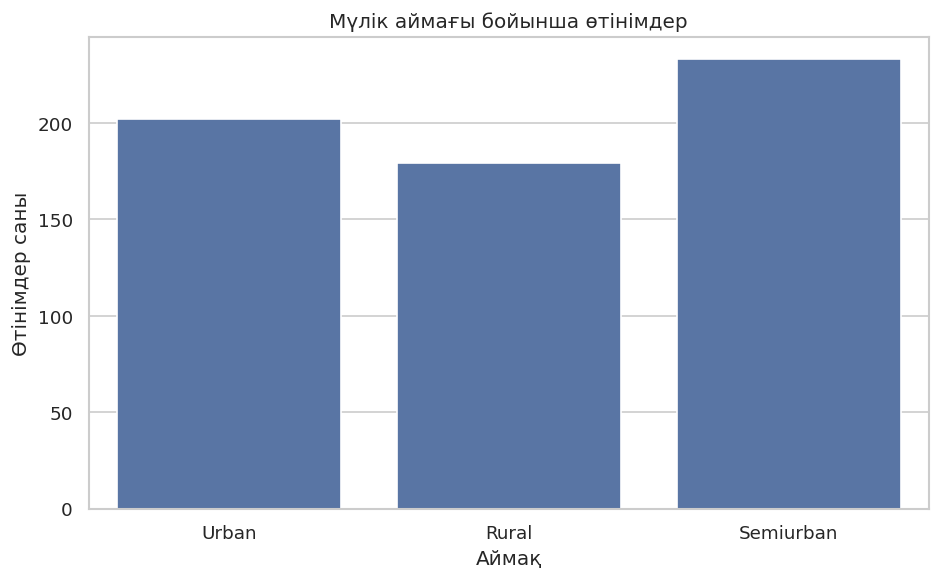

In [ ]:
# 2.5 Мүлік аймағы бойынша өтінімдер саны
# TODO 14: 'Property_Area' бойынша countplot
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Property_Area', ax=ax)
ax.set_title('Мүлік аймағы бойынша өтінімдер')
ax.set_xlabel('Аймақ')
ax.set_ylabel('Өтінімдер саны')
plt.tight_layout()
plt.show()


Descriptive нәтижесі:
- Мақұлданған несиелер пайызы: 68,73%
- Ең көп өтінім берген аймақ: Жартылай қала
- Несие сомасының орташа мәні: 146,41

# 3. DIAGNOSTIC ТАЛДАУ — "Кімдер неге бас тартуға ұшырайды?"


In [ ]:
print("\n=== 3. DIAGNOSTIC ТАЛДАУ ===")

# 3.1 Білім деңгейі бойынша мақұлдау пайызы
print("\n--- Білім бойынша мақұлдау пайызы ---")
# TODO 15: 'Education' бойынша топтап, 'Loan_Status_num' орташасын есептеу
#          (орташа = мақұлдау пайызы)
df['Loan_Status_num'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df_edu = (df.groupby('Education')['Loan_Status_num']
    .mean()
    .reset_index()
    .sort_values('Loan_Status_num', ascending=False))
print(df_edu)


=== 3. DIAGNOSTIC ТАЛДАУ ===

--- Білім бойынша мақұлдау пайызы ---
      Education  Loan_Status_num
0      Graduate         0.708333
1  Not Graduate         0.611940


In [ ]:
# 3.2 Несие тарихы бойынша мақұлдау
print("\n--- Несие тарихы бойынша мақұлдау ---")
# TODO 16: 'Credit_History' бойынша топтап, 'Loan_Status_num' орташасы
print(df.groupby('Credit_History')['Loan_Status_num'].mean())


--- Несие тарихы бойынша мақұлдау ---
Credit_History
0.0    0.078652
1.0    0.790476
Name: Loan_Status_num, dtype: float64


Text(0, 0.5, 'Табыс')

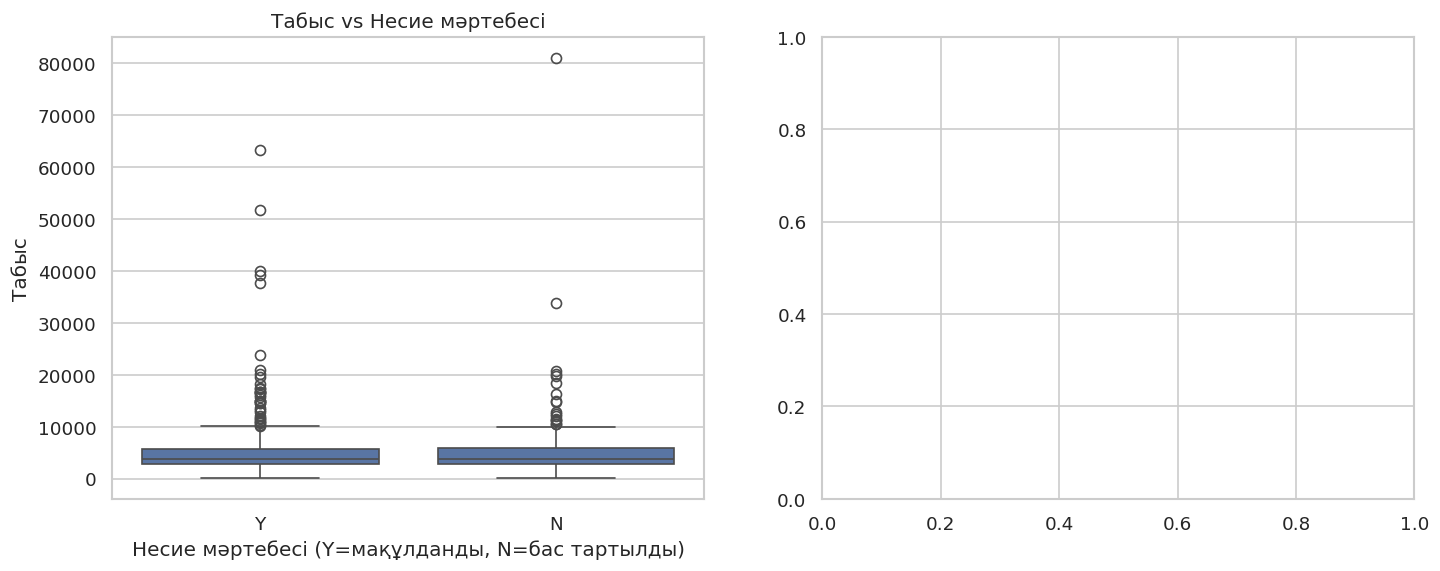

In [ ]:
# 3.3 Визуализация — Boxplot: табыс vs несие мәртебесі
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO 17: 'Loan_Status' бойынша 'ApplicantIncome' boxplot
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', ax=axes[0])
axes[0].set_title('Табыс vs Несие мәртебесі')
axes[0].set_xlabel('Несие мәртебесі (Y=мақұлданды, N=бас тартылды)')
axes[0].set_ylabel('Табыс')

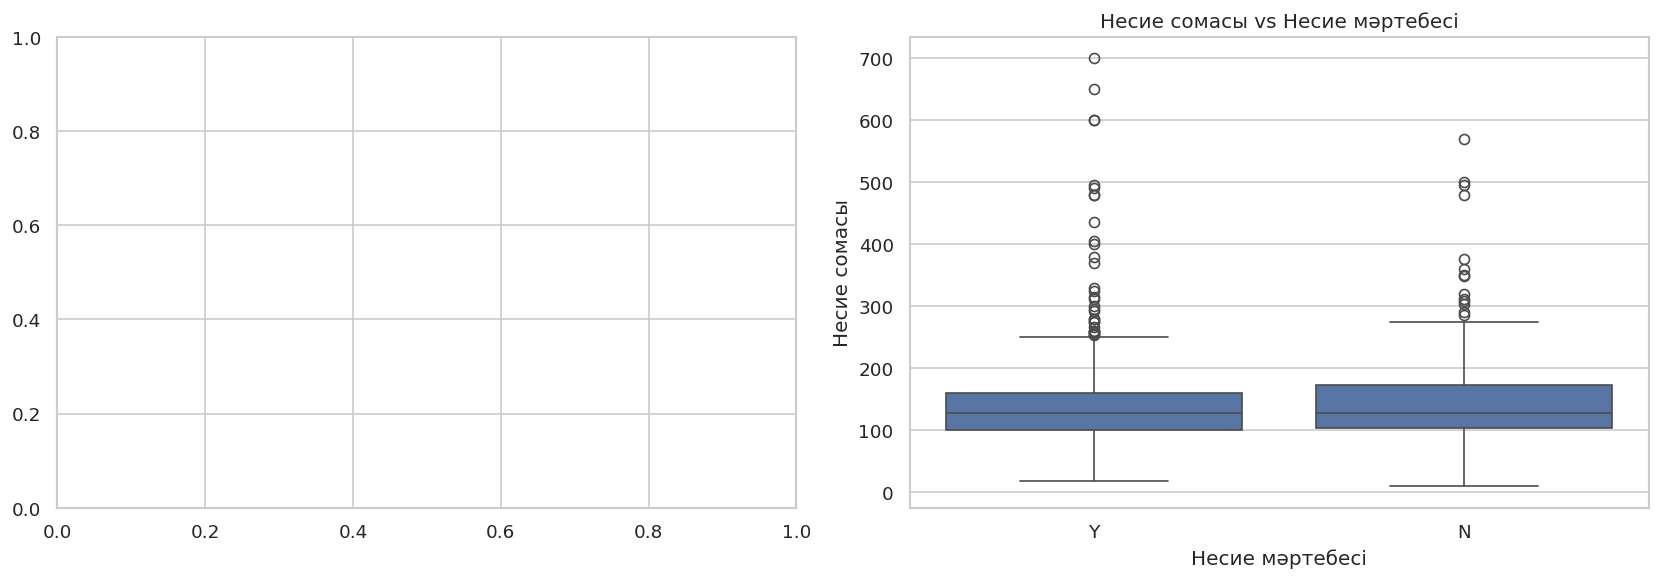

In [ ]:
# TODO 18: 'Loan_Status' бойынша 'LoanAmount' boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount', ax=axes[1])
axes[1].set_title('Несие сомасы vs Несие мәртебесі')
axes[1].set_xlabel('Несие мәртебесі')
axes[1].set_ylabel('Несие сомасы')

plt.tight_layout()
plt.show()

In [ ]:
# 3.4 Аймақ бойынша мақұлдау пайызы — pivot_table
print("\n--- Аймақ + Білім бойынша мақұлдау ---")
# TODO 19: pivot_table жаса — values='Loan_Status_num',
#           index='Property_Area', columns='Education', aggfunc='mean'
pivot = pd.pivot_table(df, values='Loan_Status_num',
                       index='Property_Area',
                       columns='Education',
                       aggfunc='mean')
print(pivot.round(2))


--- Аймақ + Білім бойынша мақұлдау ---
Education      Graduate  Not Graduate
Property_Area                        
Rural              0.64          0.54
Semiurban          0.77          0.76
Urban              0.69          0.52


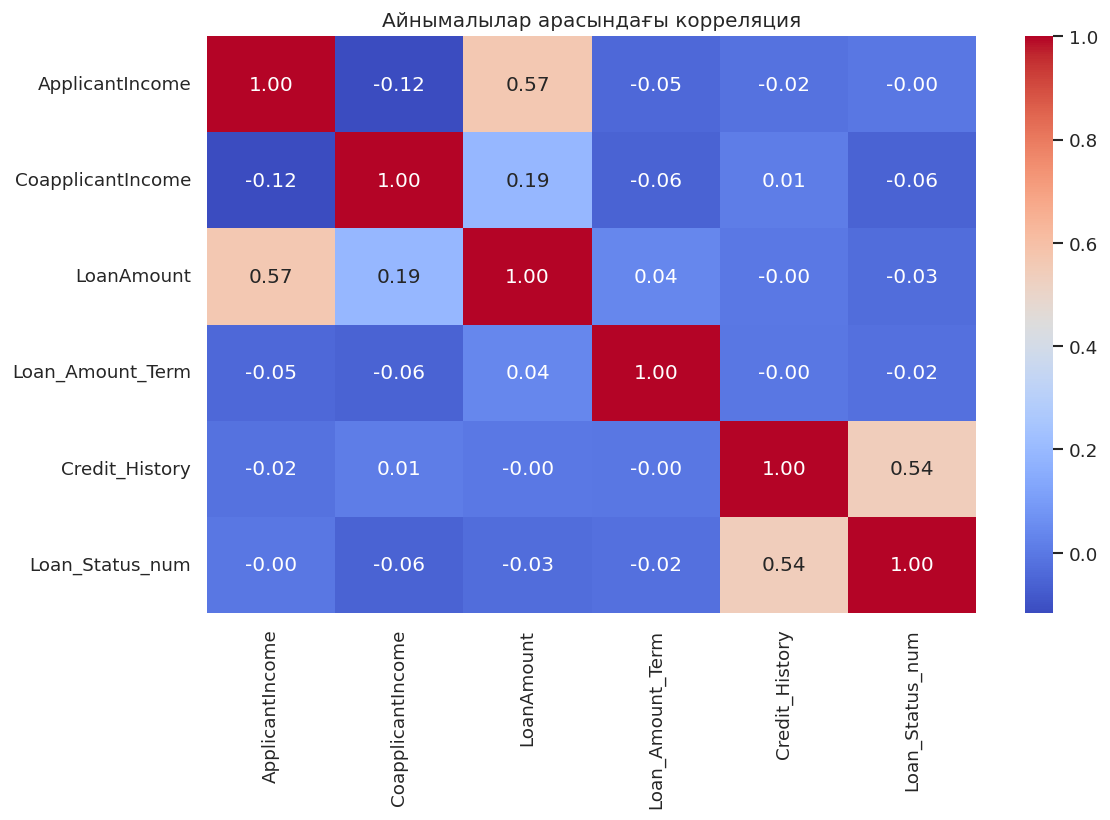

In [ ]:
# 3.5 Корреляция матрицасы
cols_corr = ['ApplicantIncome', 'CoapplicantIncome',
             'LoanAmount', 'Loan_Amount_Term',
             'Credit_History', 'Loan_Status_num']
fig, ax = plt.subplots(figsize=(10, 7))
# TODO 20: Корреляция heatmap
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Айнымалылар арасындағы корреляция')
plt.tight_layout()
plt.show()


Diagnostic нәтижесі:
- Мақұлдауға ең көп әсер ететін фактор: Credit_history,area
- Несие тарихы жоқ клиенттерде мақұлдау пайызы: 13,1%
- Ең тәуекелді аймақ: Rural(аймақтың 38,5% отказ алған)


# 4. PREDICTIVE ТАЛДАУ — "Өтінімдер динамикасы қандай?"

In [ ]:
print("\n=== 4. PREDICTIVE ТАЛДАУ ===")

# Ескерту: бұл датасетте дата бағаны жоқ,
# сондықтан Loan_ID бойынша хронологиялық ретті модельдейміз
df['loan_number'] = range(1, len(df) + 1)
df['batch'] = pd.cut(df['loan_number'], bins=10,
                     labels=[f'Кезең {i}' for i in range(1, 11)])
# TODO 21: Әр кезең бойынша өтінімдер санын есептеу
batch_counts = df.groupby('batch')['Loan_ID'].count().reset_index()
batch_counts.columns = ['batch', 'count']


=== 4. PREDICTIVE ТАЛДАУ ===


/tmp/ipykernel_2833/2911195898.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_counts = df.groupby('batch')['Loan_ID'].count().reset_index()


In [ ]:
# TODO 22: Әр кезең бойынша мақұлдау санын есепте
batch_approved = df.groupby('batch')['Loan_Status_num'].sum().reset_index()
batch_approved.columns = ['batch', 'approved']

/tmp/ipykernel_2833/3170228505.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_approved = df.groupby('batch')['Loan_Status_num'].sum().reset_index()


In [ ]:
# Біріктіру
batch_df = batch_counts.merge(batch_approved, on='batch')
batch_df['approval_rate'] = batch_df['approved'] / batch_df['count'] * 100

# TODO 23: Жинақталған өтінімдер санын есептеу (cumsum)
batch_df['cumulative'] = batch_df['count'].cumsum()


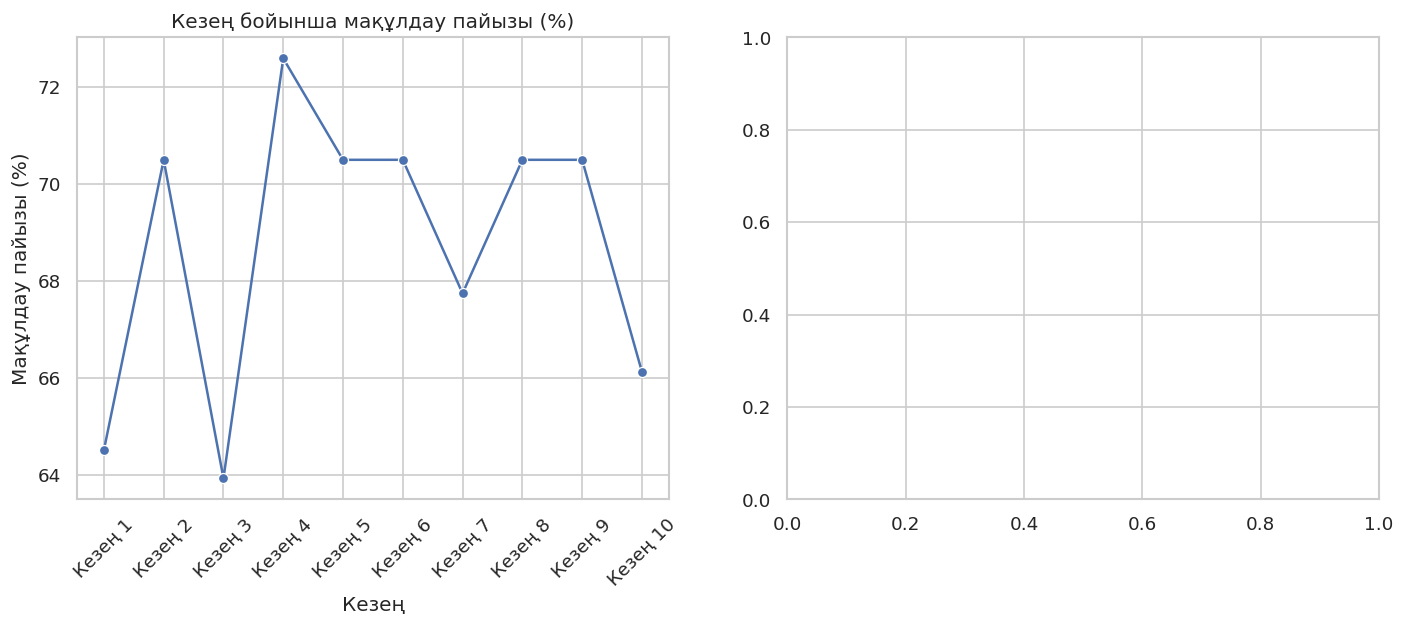

In [ ]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO 24: Кезең бойынша мақұлдау пайызы lineplot
sns.lineplot(data=batch_df, x='batch', y='approval_rate', ax=axes[0], marker='o')
axes[0].set_title('Кезең бойынша мақұлдау пайызы (%)')
axes[0].set_xlabel('Кезең')
axes[0].set_ylabel('Мақұлдау пайызы (%)')
axes[0].tick_params(axis='x', rotation=45)

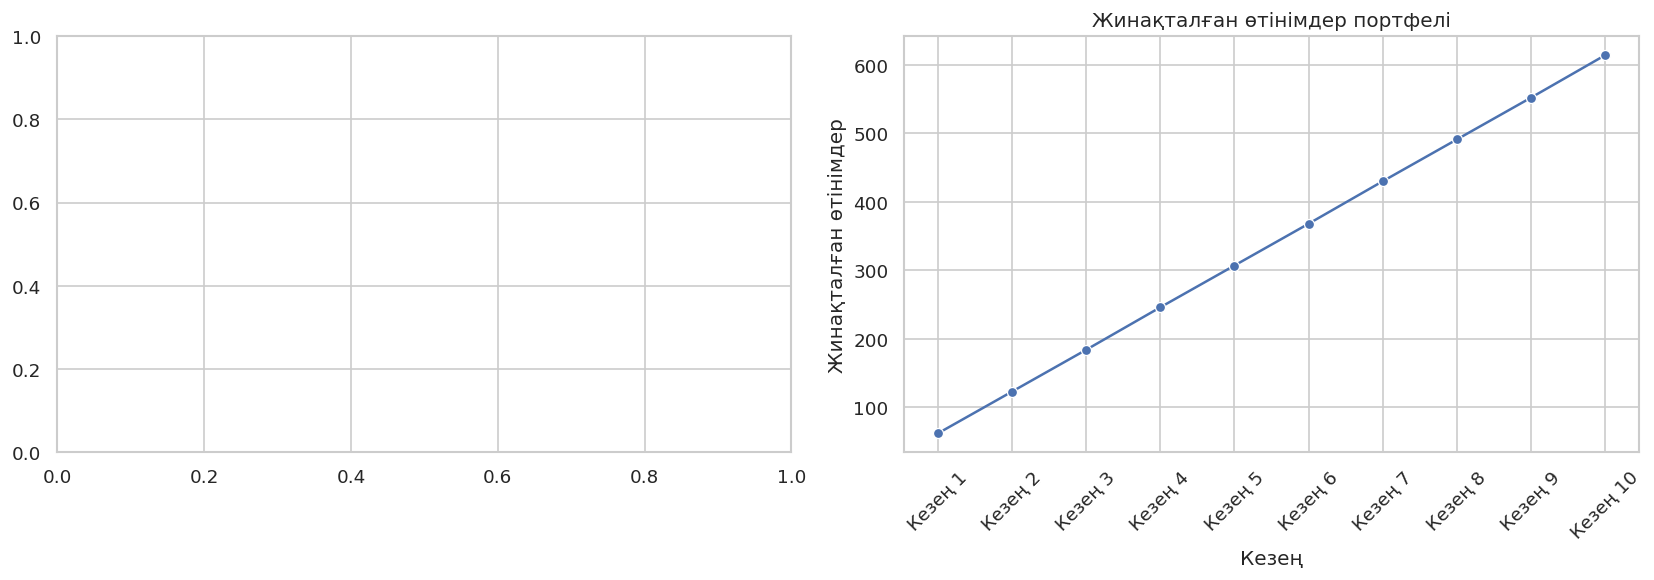

In [ ]:
# TODO 25: Жинақталған өтінімдер lineplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=batch_df, x='batch', y='cumulative', ax=axes[1], marker='o')
axes[1].set_title('Жинақталған өтінімдер портфелі')
axes[1].set_xlabel('Кезең')
axes[1].set_ylabel('Жинақталған өтінімдер')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Predictive нәтижесі:
- Мақұлдау пайызының тренді:
        -Мақұлдау трендінде 4нші кезең ең үлкен көрсеткіш көрсеткен(Самый учпешный период)
        - 1,3,10 кезеңдерде ең төмен көрсеткішті байқауға болады(рискованный кезеңдер)
        - 5-9 этаптарда стабильный

- Портфель өсімі: Жинақталған өтінімдер барлық кезеңде бірқалыпты өсіп жатыр.
                  Төмендеу жоқ.Жинақталған өтінімдер осылай жалғасатын болса келесі кезеңде 680 өтінімге дейін өсуі мүмкін.

# 5. PRESCRIPTIVE ТАЛДАУ — "Не істеу керек?"

In [ ]:
print("\n=== 5. PRESCRIPTIVE ТАЛДАУ ===")

# 5.1 "Сенімді қарыз алушы" портреті
print("\n--- Мақұлданған клиенттің орташа көрсеткіштері ---")
approved = df[df['Loan_Status'] == 'Y']
rejected = df[df['Loan_Status'] == 'N']

# TODO 26: Мақұлданған клиенттердің орташа табысы мен несие сомасы
print("Мақұлданған:")
print(approved[['ApplicantIncome', 'LoanAmount']].mean())


=== 5. PRESCRIPTIVE ТАЛДАУ ===

--- Мақұлданған клиенттің орташа көрсеткіштері ---
Мақұлданған:
ApplicantIncome    5384.068720
LoanAmount          143.869668
dtype: float64


In [ ]:
print("\nБас тартылған:")
# TODO 27: Бас тартылған клиенттердің орташа табысы мен несие сомасы
print(rejected[['ApplicantIncome', 'LoanAmount']].mean())


Бас тартылған:
ApplicantIncome    5446.078125
LoanAmount          149.890625
dtype: float64


In [ ]:
# 5.2 Аймақ бойынша мақұлдау пайызы
print("\n--- Аймақ бойынша мақұлдау пайызы ---")
# TODO 28: 'Property_Area' бойынша топтап, мақұлдау пайызы
area_approval = (df.groupby('Property_Area')['Loan_Status_num']
                   .mean()
                   .reset_index()
                   .sort_values('Loan_Status_num', ascending=False))
print(area_approval)


--- Аймақ бойынша мақұлдау пайызы ---
  Property_Area  Loan_Status_num
1     Semiurban         0.768240
2         Urban         0.658416
0         Rural         0.614525


Text(0.5, 1.0, 'Аймақ бойынша өтінімдер мен мақұлдау')

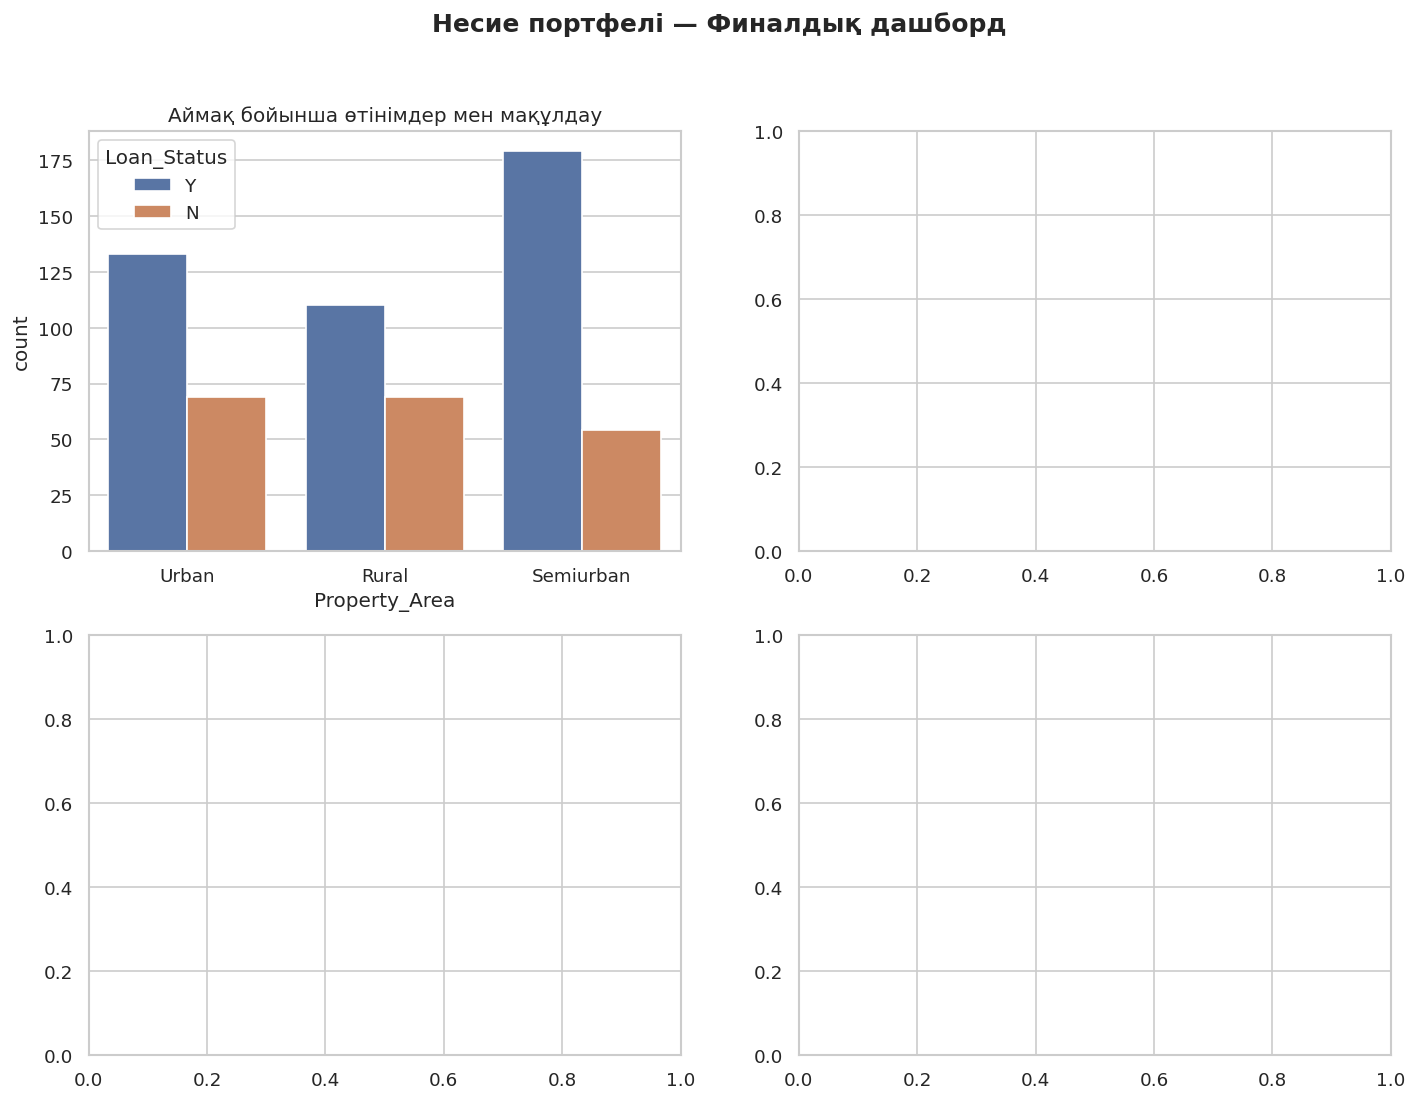

In [ ]:
# 5.3 Финалдық дашборд
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Несие портфелі — Финалдық дашборд',
             fontsize=15, fontweight='bold')

# Граф 1: Аймақ бойынша өтінімдер
sns.countplot(data=df, x='Property_Area',
              hue='Loan_Status', ax=axes[0, 0])
axes[0, 0].set_title('Аймақ бойынша өтінімдер мен мақұлдау')

Text(0, 0.5, 'Мақұлдау пайызы')

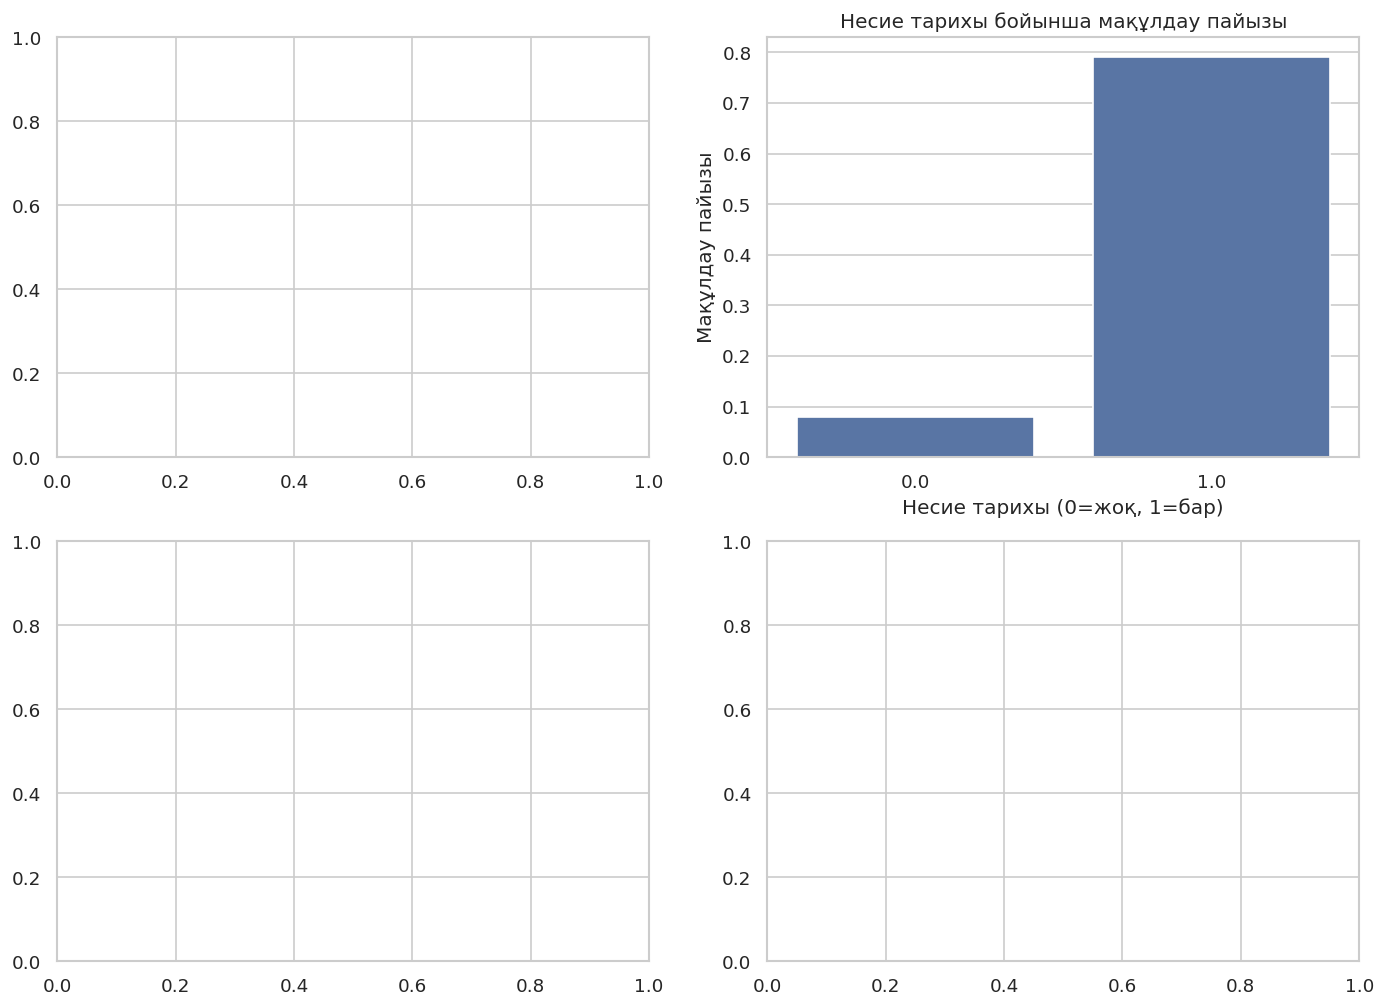

In [ ]:
# Граф 2: Несие тарихы бойынша мақұлдау
# TODO 29: Credit_History бойынша Loan_Status_num орташасы barplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ch_df = df.groupby('Credit_History')['Loan_Status_num'].mean().reset_index()
sns.barplot(data=ch_df, x='Credit_History', y='Loan_Status_num', ax=axes[0, 1])
axes[0, 1].set_title('Несие тарихы бойынша мақұлдау пайызы')
axes[0, 1].set_xlabel('Несие тарихы (0=жоқ, 1=бар)')
axes[0, 1].set_ylabel('Мақұлдау пайызы')

Text(0.5, 1.0, 'Табыс vs Несие мәртебесі')

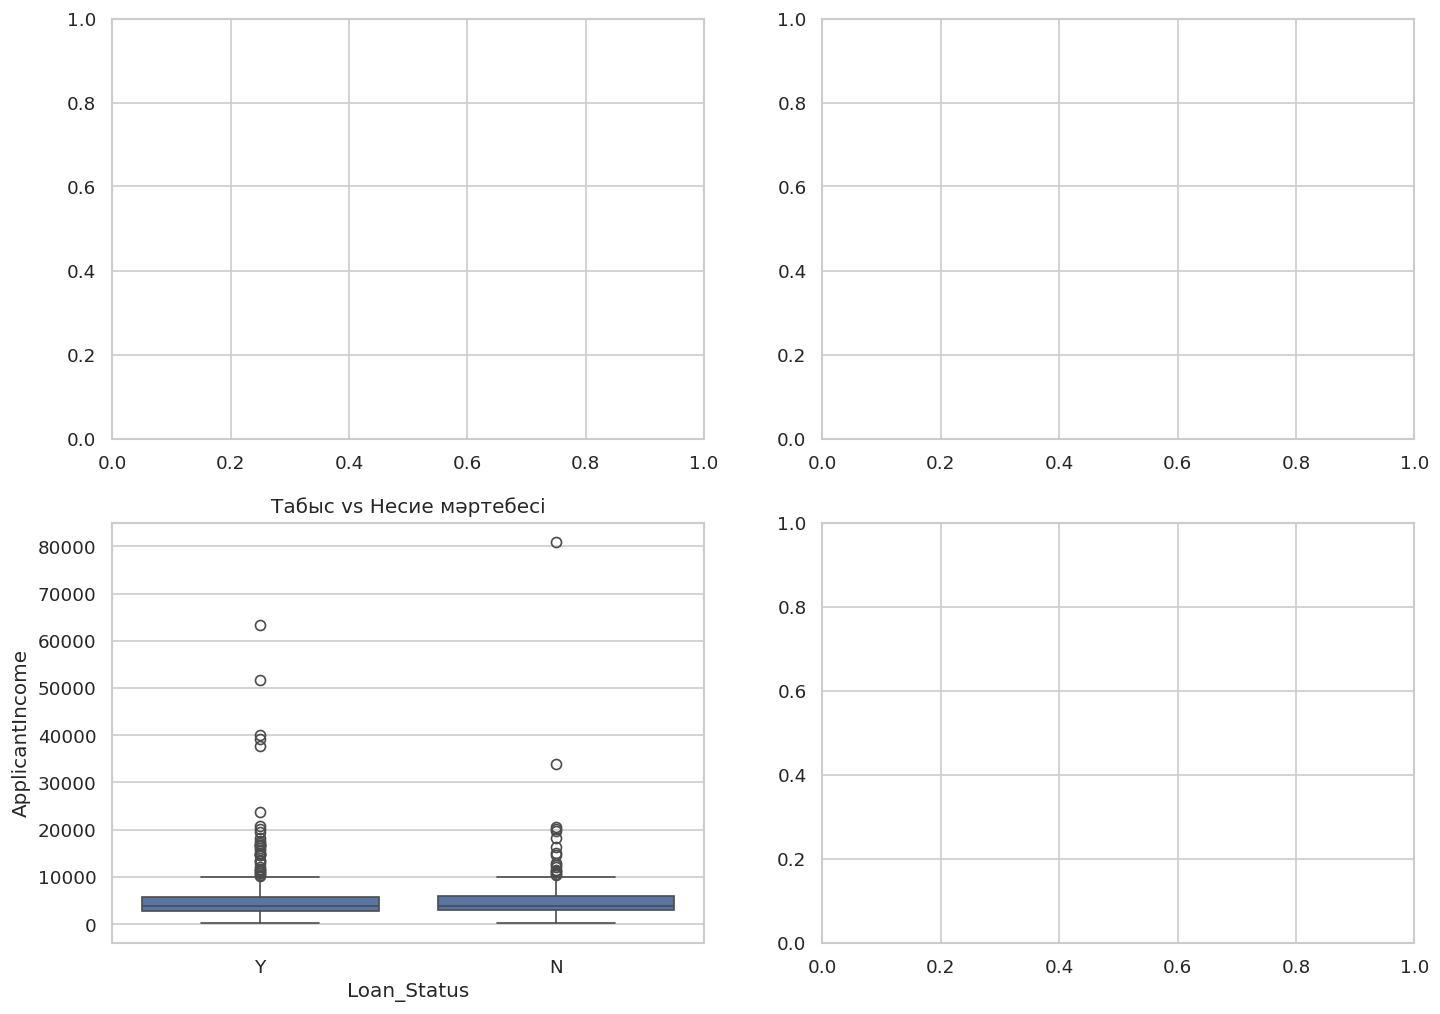

In [ ]:
# Граф 3: Табыс vs Несие мәртебесі boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', ax=axes[1, 0])
axes[1, 0].set_title('Табыс vs Несие мәртебесі')

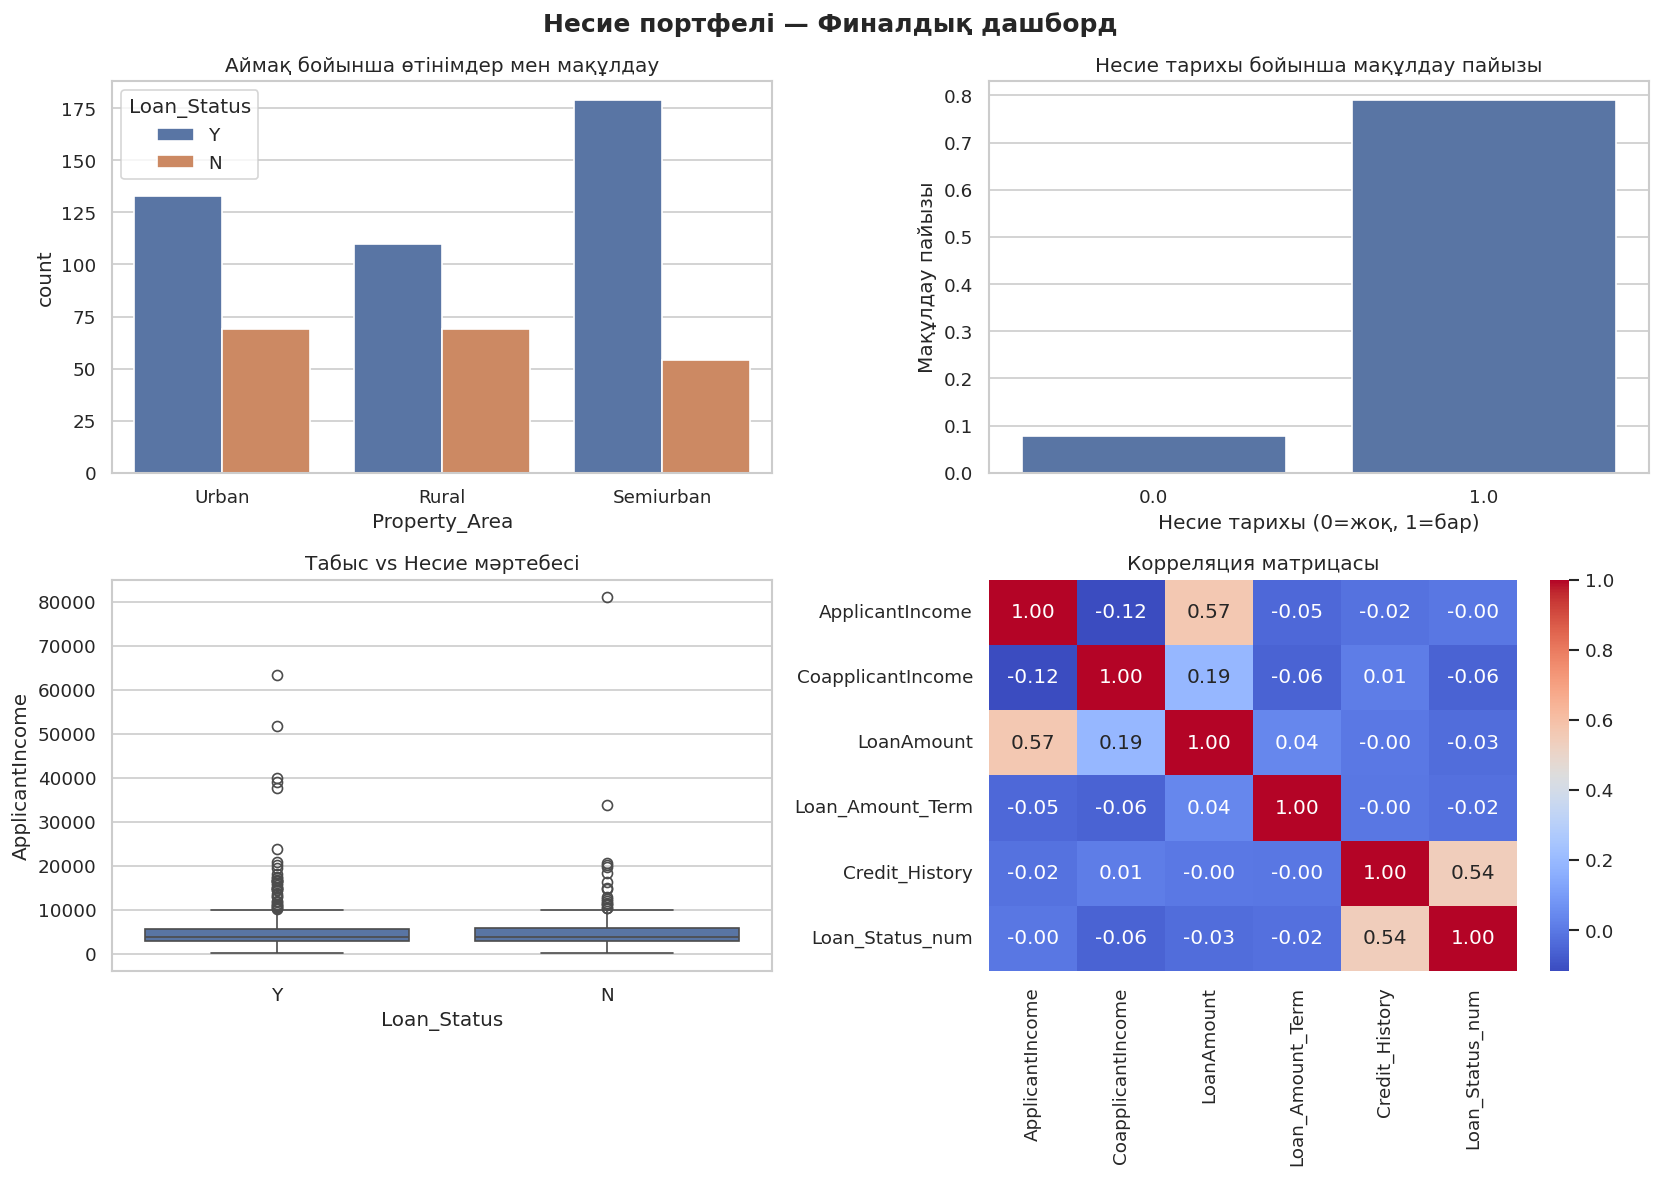

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Несие портфелі — Финалдық дашборд',
             fontsize=15, fontweight='bold')
# Граф 1: Аймақ бойынша өтінімдер
sns.countplot(data=df, x='Property_Area',
              hue='Loan_Status', ax=axes[0, 0])
axes[0, 0].set_title('Аймақ бойынша өтінімдер мен мақұлдау')
# Граф 2: Несие тарихы бойынша мақұлдау
# TODO 29: Credit_History бойынша Loan_Status_num орташасы barplot
ch_df = df.groupby('Credit_History')['Loan_Status_num'].mean().reset_index()
sns.barplot(data=ch_df, x='Credit_History', y='Loan_Status_num', ax=axes[0, 1])
axes[0, 1].set_title('Несие тарихы бойынша мақұлдау пайызы')
axes[0, 1].set_xlabel('Несие тарихы (0=жоқ, 1=бар)')
axes[0, 1].set_ylabel('Мақұлдау пайызы')
# Граф 3: Табыс vs Несие мәртебесі boxplot
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome', ax=axes[1, 0])
axes[1, 0].set_title('Табыс vs Несие мәртебесі')
# Граф 4: Корреляция
sns.heatmap(df[cols_corr].corr(), annot=True,
            cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title('Корреляция матрицасы')

plt.tight_layout()
plt.show()

# 6. ҚОРЫТЫНДЫ ҰСЫНЫСТАР (өз сөзіңмен толтыр)


In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           ІСКЕРЛІК ҰСЫНЫСТАР                                 ║
╠══════════════════════════════════════════════════════════════╣
║  1. Сенімді қарыз алушы профилі: - несие тарихы жақсы        ║
║                                  - loanAmount табысына сай   ║
║                                   - property_area->SemiUrban ║
║                                   - несиені уақытында өтеу   ║
║                                   ықтималдығы жоғары         ║
║                                                              ║
║  2. Ең тәуекелді топ:             - несие тарихы нашар       ║
║                                   - Ауыл аймақта тұратындар  ║
║                                   - Айлық табысы аз          ║
║                                                              ║
║   3. Мақұлдауды арттыру үшін:      - несие тарихына көп көңіл║
║                                    бөлу керек                ║
║                                    - айлық табысына сай несие║
║                                     ұсыну                    ║
║                                    - несие тарихы нашар      ║
║                                      клиенттерге арнайы      ║
║                                      бағдарлама жасау        ║
║  4. Ең перспективті аймақ:     SemiUrban себебі заявка саны  ║
║   жағынан және мақұлдау жағынан басқа аймақтарға қарағанда   ║
║    әлдеқайда үлкен көрсеткіш көрсетті                        ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           ІСКЕРЛІК ҰСЫНЫСТАР                                 ║
╠══════════════════════════════════════════════════════════════╣
║  1. Сенімді қарыз алушы профилі: - несие тарихы жақсы        ║
║                                  - loanAmount табысына сай   ║
║                                   - property_area->SemiUrban ║
║                                   - несиені уақытында өтеу   ║
║                                   ықтималдығы жоғары         ║
║                                                              ║
║  2. Ең тәуекелді топ:             - несие тарихы нашар       ║
║                                   - Ауыл аймақта тұратындар  ║
║                                   - Айлық табысы аз          ║
║                                                              ║
║   3. Мақұлдауды арттыру үшін:      - несие тарихына көп көңіл║
║                                    бөлу керек                ║
║                       